# Chapter 13 — F Distribution and One-Way ANOVA

Comparing several group means at once by weighing between-group against within-group variation.

| Section | What it covers |
|---|---|
| 13.1 | The idea of ANOVA |
| 13.2 | The F distribution and the decision |

**How to use this notebook.** Read a short explanation, run the worked cell under it, then do the
**Your turn** cell yourself. The worked cells already show their output, so you can check your
answer against them. Nothing here is graded and nothing is hidden, so break things freely and
re-run the setup cell if you get lost.

The matching page on the website is [F Distribution and One-Way ANOVA](https://khh-aka-lucifer.github.io/statLab/chapters/anova/), where the same ideas are
sliders and draggable points instead of code. Use both. The website builds the intuition, and the
notebook shows you how to do it to data of your own.

In [1]:
# Run me first. Everything below needs this cell.
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# The same colours the StatLab website uses, so your charts match the demos.
C = {
    "accent": "#2E7D6B", "accent_strong": "#1F5A4D", "accent_soft": "#D9EBE5",
    "ink": "#282725", "ink_soft": "#6B6560", "line": "#E4E0DA",
    "cat1": "#2E7D6B", "cat2": "#B5763F", "cat3": "#4E7DA6",
    "cat4": "#9A5D8F", "cat5": "#8A8F3C",
    "ok": "#4C8B57", "warn": "#C06A2E",
}

plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.dpi": 110,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": C["line"], "axes.labelcolor": C["ink"],
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": C["line"], "grid.linewidth": 0.8,
    "text.color": C["ink"], "xtick.color": C["ink_soft"], "ytick.color": C["ink_soft"],
    "font.size": 11, "axes.titlesize": 12, "legend.frameon": False,
})

# Works whether you launched Jupyter inside code/ or at the repo root.
DATA = Path("data") if Path("data").exists() else Path("code/data")

# One seed, so your numbers match the text. Change it and the randomness changes with you.
rng = np.random.default_rng(12345)

print("Ready. pandas", pd.__version__, "| numpy", np.__version__)

Ready. pandas 3.0.3 | numpy 2.4.4


## Three groups, one test

Comparing two means took one t-test. Comparing three or more takes a single test on all of them,
because running three separate t-tests inflates the false-alarm rate.

**Analysis of variance** asks whether the group means sit further apart than the scatter inside the
groups can explain.

In [2]:
penguins = pd.read_csv(DATA / "penguins.csv").dropna(subset=["body_mass_g"])
species = ["Adelie", "Chinstrap", "Gentoo"]
groups = [penguins.loc[penguins["species"] == s, "body_mass_g"].to_numpy() for s in species]

for name, g in zip(species, groups):
    print(f"{name:10s} n = {len(g):3d}   mean = {g.mean():7.1f} g   sd = {g.std(ddof=1):6.1f} g")

grand = penguins["body_mass_g"].mean()
print(f"\ngrand mean = {grand:.1f} g")

Adelie     n = 151   mean =  3700.7 g   sd =  458.6 g
Chinstrap  n =  68   mean =  3733.1 g   sd =  384.3 g
Gentoo     n = 123   mean =  5076.0 g   sd =  504.1 g

grand mean = 4201.8 g


### Why not three t-tests

Each test at $\alpha = 0.05$ has a 5 % false-alarm rate. Run three and the chance of at least one
false alarm is much higher than 5 %. Measure it rather than trusting the arithmetic.

In [3]:
pooled = penguins["body_mass_g"].to_numpy()

false_alarms_pairwise = 0
false_alarms_anova = 0
runs = 2000

for _ in range(runs):
    # three groups drawn from ONE population, so every difference is pure chance
    a, b, c = (rng.choice(pooled, 50, replace=True) for _ in range(3))
    pairwise = [stats.ttest_ind(a, b, equal_var=False).pvalue,
                stats.ttest_ind(a, c, equal_var=False).pvalue,
                stats.ttest_ind(b, c, equal_var=False).pvalue]
    false_alarms_pairwise += any(p < 0.05 for p in pairwise)
    false_alarms_anova += stats.f_oneway(a, b, c).pvalue < 0.05

print(f"three pairwise t-tests, at least one p < 0.05: {false_alarms_pairwise/runs:.3f}")
print(f"one ANOVA,                        p < 0.05: {false_alarms_anova/runs:.3f}")
print("\nThe ANOVA holds its promise. The pairwise approach does not.")

three pairwise t-tests, at least one p < 0.05: 0.113
one ANOVA,                        p < 0.05: 0.049

The ANOVA holds its promise. The pairwise approach does not.


## 13.1 The idea of ANOVA

$F$ is a ratio of two averaged squared distances,

$$F = \frac{MS_{\text{between}}}{MS_{\text{within}}}$$

The top measures how far the group means sit from the grand mean. The bottom measures how far the
points sit from their own group's mean. Neither means anything alone.

In [4]:
k = len(groups)
n_total = sum(len(g) for g in groups)

ss_between = sum(len(g) * (g.mean() - grand)**2 for g in groups)
ss_within  = sum(((g - g.mean())**2).sum() for g in groups)

df_between, df_within = k - 1, n_total - k
ms_between, ms_within = ss_between / df_between, ss_within / df_within
F = ms_between / ms_within

print(f"SS between = {ss_between:12.1f}   df = {df_between:3d}   MS = {ms_between:10.1f}")
print(f"SS within  = {ss_within:12.1f}   df = {df_within:3d}   MS = {ms_within:10.1f}")
print(f"\nF = {ms_between:.1f} / {ms_within:.1f} = {F:.3f}")
print(f"\nscipy: {stats.f_oneway(*groups)}")

SS between =  146864214.2   df =   2   MS = 73432107.1
SS within  =   72443483.2   df = 339   MS =   213697.6

F = 73432107.1 / 213697.6 = 343.626

scipy: F_onewayResult(statistic=np.float64(343.62627520548114), pvalue=np.float64(2.8923681333772844e-82))


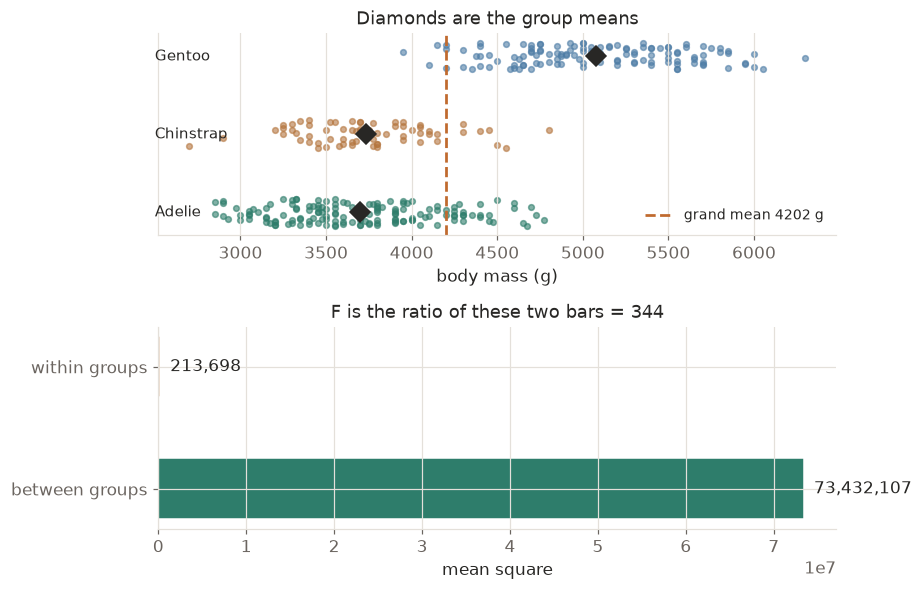

In [5]:
fig, (top, bottom) = plt.subplots(2, 1, figsize=(8.5, 5.5))

colours = [C["cat1"], C["cat2"], C["cat3"]]
for i, (name, g, colour) in enumerate(zip(species, groups, colours)):
    jitter = rng.uniform(-0.18, 0.18, len(g))
    top.scatter(g, np.full(len(g), i) + jitter, s=14, color=colour, alpha=0.6)
    top.plot(g.mean(), i, "D", color=C["ink"], ms=9)
    top.text(2500, i, name, va="center", fontsize=10, color=C["ink"])
top.axvline(grand, color=C["warn"], ls="--", lw=1.8, label=f"grand mean {grand:.0f} g")
top.set_yticks([]); top.set_xlabel("body mass (g)")
top.set_title("Diamonds are the group means"); top.legend(loc="lower right", fontsize=9)

bottom.barh(["between groups", "within groups"], [ms_between, ms_within],
            color=[C["accent"], C["cat2"]], height=0.5, edgecolor="white")
for i, v in enumerate([ms_between, ms_within]):
    bottom.text(v, i, f"  {v:,.0f}", va="center", color=C["ink"])
bottom.set_xlabel("mean square")
bottom.set_title(f"F is the ratio of these two bars = {F:.0f}")

plt.tight_layout()
plt.show()

The between-groups bar dwarfs the within-groups bar, so $F$ is enormous. That is what a real
difference looks like.

Now break it on purpose. Widen the groups without moving their means and $F$ collapses, because the
same gaps stop being impressive against louder noise.

In [6]:
for spread in [1.0, 2.0, 4.0, 8.0]:
    noisy = [g.mean() + (g - g.mean()) * spread for g in groups]   # same means, wider spread
    print(f"spread x {spread:.0f}   F = {stats.f_oneway(*noisy).statistic:9.2f}   "
          f"p = {stats.f_oneway(*noisy).pvalue:.2e}")

spread x 1   F =    343.63   p = 2.89e-82
spread x 2   F =     85.91   p = 6.58e-31
spread x 4   F =     21.48   p = 1.65e-09
spread x 8   F =      5.37   p = 5.06e-03


In [ ]:
# Your turn.
# Run a one-way ANOVA on bill_depth_mm across the three species.
# 1. Compute F by hand from the sums of squares, then check against stats.f_oneway.
# 2. Is the result as clear-cut as body mass was?
# 3. Now run it on flipper_length_mm and compare all three F statistics.

...

## 13.2 The F distribution and the decision

When every group really does come from the same distribution, $F$ still varies from study to study,
and its values follow the **F distribution** with $k-1$ and $n-k$ degrees of freedom.

The test is one-tailed by construction, because only a large $F$ is evidence against equal means.

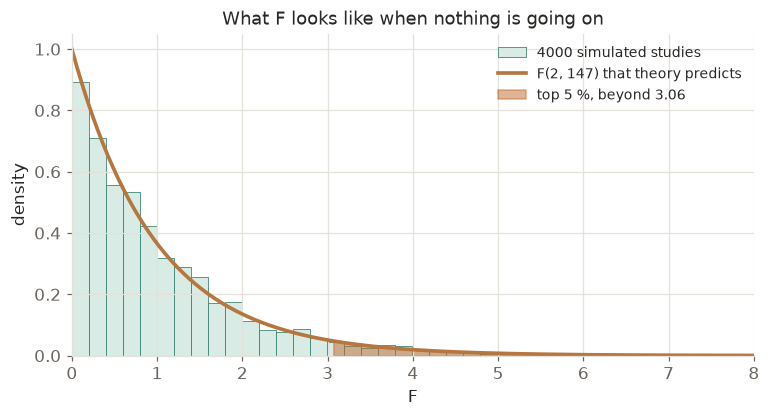

share of simulated studies beyond the critical value: 0.0517
our observed F was 343.6, which is off this chart entirely


In [7]:
# simulate the null: three groups from one population
null_F = np.array([stats.f_oneway(*(rng.choice(pooled, 50, replace=True) for _ in range(3))).statistic
                   for _ in range(4000)])

df1, df2 = 2, 3*50 - 3
critical = stats.f.ppf(0.95, df1, df2)

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.hist(null_F, bins=60, density=True, color=C["accent_soft"], edgecolor=C["accent"],
        linewidth=0.5, label="4000 simulated studies")
grid = np.linspace(0, 8, 400)
ax.plot(grid, stats.f.pdf(grid, df1, df2), color=C["cat2"], lw=2.4,
        label=f"F({df1}, {df2}) that theory predicts")
tail = grid >= critical
ax.fill_between(grid[tail], stats.f.pdf(grid[tail], df1, df2), color=C["warn"], alpha=0.5,
                label=f"top 5 %, beyond {critical:.2f}")

ax.set_xlim(0, 8); ax.set_xlabel("F"); ax.set_ylabel("density")
ax.set_title("What F looks like when nothing is going on")
ax.legend(fontsize=9)
plt.show()

print(f"share of simulated studies beyond the critical value: {(null_F > critical).mean():.4f}")
print(f"our observed F was {F:.1f}, which is off this chart entirely")

The simulated histogram lands on the theoretical curve, and about 5 % of studies cross the line even
though all three groups came from one population. That 5 % is the significance level, working as
advertised.

Our real $F$ of 343 is so far right that it does not fit on the axis.

### What ANOVA does not tell you

A significant $F$ says the means are not all equal. It does not say which ones differ. For that you
need a follow-up that controls the error rate across the comparisons.

In [8]:
print("pairwise comparisons, with a Bonferroni correction for running three of them:")
alpha, m = 0.05, 3
for i in range(3):
    for j in range(i+1, 3):
        p = stats.ttest_ind(groups[i], groups[j], equal_var=False).pvalue
        verdict = "differ" if p < alpha/m else "no evidence"
        print(f"  {species[i]:10s} vs {species[j]:10s}   p = {p:.3e}   "
              f"(threshold {alpha/m:.4f})  ->  {verdict}")

pairwise comparisons, with a Bonferroni correction for running three of them:
  Adelie     vs Chinstrap    p = 5.879e-01   (threshold 0.0167)  ->  no evidence
  Adelie     vs Gentoo       p = 7.710e-65   (threshold 0.0167)  ->  differ
  Chinstrap  vs Gentoo       p = 3.414e-48   (threshold 0.0167)  ->  differ


Gentoo differ from both of the others, and Adelie and Chinstrap show no evidence of differing in
mass. The single ANOVA p-value could never have told you that.

In [ ]:
# Your turn.
# ANOVA assumes the groups have roughly equal spreads. Check that assumption here.
# 1. Compare the three standard deviations.
# 2. Run stats.levene on the three groups. What does it conclude?
# 3. Look up the Kruskal-Wallis test (stats.kruskal), which does not need normality,
#    and compare its verdict with the ANOVA.

...

## Exercises

1. **ANOVA with two groups.** Run a one-way ANOVA on just Adelie and Gentoo, and a pooled-variance
   t-test on the same two. Confirm that $F = t^2$. They are the same test.

2. **Where the power goes.** Using penguin bill depth, find by simulation how many birds per species
   you would need for 80 % power. Compare with body mass, where the effect is far larger.

3. **Unequal group sizes.** Gentoo has 123 birds and Chinstrap 68. Artificially trim all groups to
   68 and rerun. How much power did the extra Gentoo data buy?

4. **Two-way ANOVA.** Species is not the only grouping. Add sex and look at both factors at once
   using `statsmodels`' formula interface. Does the species effect survive?

5. **The assumption that matters most.** ANOVA is fairly robust to non-normality and much less robust
   to unequal variances with unequal group sizes. Demonstrate that by simulating three groups with
   very different spreads and sizes, and measuring the actual false-alarm rate.

## What you should take away

ANOVA compares the spread between group means against the spread inside the groups, and only the
ratio decides. You saw both halves matter by widening the groups without moving their means and
watching $F$ collapse.

A single ANOVA protects the false-alarm rate in a way that three separate t-tests do not, which you
measured rather than assumed. And a significant $F$ is only the beginning, because it says the means
are not all equal without saying which.

---

*StatLab, by Dr. Sein Minn and Kaung Hein Htet. Code MIT, text CC BY 4.0.
Follows OpenStax [Introductory Statistics](https://openstax.org) (Illowsky & Dean, CC BY 4.0).*